# Pipeline de Score de Crédit — version mémoire maîtrisée

Ce notebook regroupe les phases demandées par le projet :

1. **Data Quality**
2. **Validation YAML + Pandera**
3. **Feature engineering + tests unitaires**
4. **Construction de `train_final` / `test_final`**
5. **Modélisation XGBoost**
6. **Analyse d'équité**
7. **Drift monitoring**
8. **Exports pour le dashboard**

Cette version a été pensée pour **éviter les crashs RAM** :
- chargement **séquentiel** des datasets au lieu de tout garder en mémoire,
- `usecols` pour lire seulement les colonnes utiles,
- réduction mémoire des types numériques,
- validations Pandera **sur échantillons** pour les très grosses tables,
- agrégations puis **suppression immédiate** des DataFrames intermédiaires,
- cross-validation et tuning en `n_jobs=1`,
- drift et SHAP sur **échantillons limités**.

## 0. Imports et configuration

In [1]:
import os
import gc
import sys
import time
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

SEED = 42
np.random.seed(SEED)

In [2]:
def find_project_root(start: Path | None = None) -> Path:
    start = Path.cwd() if start is None else Path(start)
    candidates = [start] + list(start.parents)
    markers = [
        ("data", "raw"),
        ("data", "processed"),
    ]
    for base in candidates:
        if all((base / a / b).exists() for a, b in markers):
            return base
    # fallback simple : répertoire courant
    return Path.cwd()

PROJECT_ROOT = find_project_root()
DATA_RAW = PROJECT_ROOT / "data" / "raw"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
CONFIG_DIR = PROJECT_ROOT / "configs"
MODEL_DIR = PROJECT_ROOT / "models"
DRIFT_DIR = PROJECT_ROOT / "drift"

for p in [DATA_PROCESSED, CONFIG_DIR, MODEL_DIR, DRIFT_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT :", PROJECT_ROOT)
print("DATA_RAW     :", DATA_RAW)
print("DATA_PROCESSED:", DATA_PROCESSED)

PROJECT_ROOT : /home/alouiyaz/projects/Qualité_controle_données
DATA_RAW     : /home/alouiyaz/projects/Qualité_controle_données/data/raw
DATA_PROCESSED: /home/alouiyaz/projects/Qualité_controle_données/data/processed


## 1. Fonctions utilitaires mémoire

In [3]:
def mem_mb(df: pd.DataFrame) -> float:
    return df.memory_usage(deep=True).sum() / 1024**2


def reduce_mem_usage(df: pd.DataFrame, verbose: bool = True) -> pd.DataFrame:
    start_mem = mem_mb(df)
    for col in df.columns:
        col_type = df[col].dtype

        if pd.api.types.is_datetime64_any_dtype(col_type):
            continue

        if pd.api.types.is_integer_dtype(col_type):
            c_min, c_max = df[col].min(), df[col].max()
            if pd.isna(c_min) or pd.isna(c_max):
                continue
            if np.iinfo(np.int8).min <= c_min <= c_max <= np.iinfo(np.int8).max:
                df[col] = df[col].astype(np.int8)
            elif np.iinfo(np.int16).min <= c_min <= c_max <= np.iinfo(np.int16).max:
                df[col] = df[col].astype(np.int16)
            elif np.iinfo(np.int32).min <= c_min <= c_max <= np.iinfo(np.int32).max:
                df[col] = df[col].astype(np.int32)
            else:
                df[col] = df[col].astype(np.int64)

        elif pd.api.types.is_float_dtype(col_type):
            c_min, c_max = df[col].min(), df[col].max()
            if pd.isna(c_min) or pd.isna(c_max):
                continue
            if np.finfo(np.float16).min <= c_min <= c_max <= np.finfo(np.float16).max:
                df[col] = df[col].astype(np.float16)
            elif np.finfo(np.float32).min <= c_min <= c_max <= np.finfo(np.float32).max:
                df[col] = df[col].astype(np.float32)
            else:
                df[col] = df[col].astype(np.float64)

    end_mem = mem_mb(df)
    if verbose:
        print(f"Mémoire: {start_mem:,.2f} MB -> {end_mem:,.2f} MB ({100*(start_mem-end_mem)/max(start_mem,1e-9):.1f}% gagnés)")
    return df


def flatten_columns(df: pd.DataFrame, prefix: str, key_cols=("SK_ID_CURR", "SK_ID_BUREAU", "SK_ID_PREV")) -> pd.DataFrame:
    new_cols = []
    for col in df.columns:
        if col in key_cols:
            new_cols.append(col)
        elif isinstance(col, tuple):
            parts = [str(c) for c in col if str(c) != ""]
            new_cols.append(f"{prefix}_{'_'.join(parts).upper()}")
        else:
            new_cols.append(f"{prefix}_{str(col).upper()}")
    df.columns = new_cols
    return df


def safe_sample(df: pd.DataFrame, n: int = 50000, seed: int = SEED) -> pd.DataFrame:
    if len(df) <= n:
        return df.copy()
    return df.sample(n=n, random_state=seed).copy()


def cleanup(*objs):
    for obj in objs:
        try:
            del obj
        except Exception:
            pass
    gc.collect()

In [4]:
# Colonnes minimales à lire pour chaque étape.
QC_USECOLS = {
    "application_train": None,   # profilage principal
    "application_test": None,
    "bureau": ["SK_ID_CURR", "SK_ID_BUREAU", "DAYS_CREDIT", "CREDIT_DAY_OVERDUE", "AMT_CREDIT_SUM",
               "AMT_CREDIT_SUM_DEBT", "AMT_CREDIT_SUM_OVERDUE"],
    "bureau_balance": ["SK_ID_BUREAU", "MONTHS_BALANCE", "STATUS"],
    "previous_application": ["SK_ID_CURR", "AMT_APPLICATION", "AMT_CREDIT", "AMT_ANNUITY",
                             "AMT_GOODS_PRICE", "HOUR_APPR_PROCESS_START"],
    "installments_payments": ["SK_ID_CURR", "AMT_INSTALMENT", "AMT_PAYMENT",
                              "DAYS_ENTRY_PAYMENT", "DAYS_INSTALMENT"],
    "credit_card_balance": ["SK_ID_CURR", "AMT_BALANCE", "AMT_CREDIT_LIMIT_ACTUAL",
                            "AMT_DRAWINGS_CURRENT", "AMT_PAYMENT_TOTAL_CURRENT", "SK_DPD", "SK_DPD_DEF"],
    "POS_CASH_balance": ["SK_ID_CURR", "MONTHS_BALANCE", "CNT_INSTALMENT",
                         "CNT_INSTALMENT_FUTURE", "SK_DPD", "SK_DPD_DEF"],
}

RAW_FILES = {
    "application_train": DATA_RAW / "application_train.csv",
    "application_test": DATA_RAW / "application_test.csv",
    "bureau": DATA_RAW / "bureau.csv",
    "bureau_balance": DATA_RAW / "bureau_balance.csv",
    "previous_application": DATA_RAW / "previous_application.csv",
    "installments_payments": DATA_RAW / "installments_payments.csv",
    "credit_card_balance": DATA_RAW / "credit_card_balance.csv",
    "POS_CASH_balance": DATA_RAW / "POS_CASH_balance.csv",
}

missing_files = [name for name, path in RAW_FILES.items() if not path.exists()]
if missing_files:
    print("Fichiers manquants :", missing_files)
else:
    print("Tous les CSV bruts sont détectés.")

Tous les CSV bruts sont détectés.


## 2. Phase 1 — Data Quality séquentiel

On profile les tables **une par une** pour éviter de garder l'ensemble des datasets volumineux en RAM.

In [5]:
def build_dataset_summary(name: str, df: pd.DataFrame, pk: str | None = None) -> dict:
    duplicate_pk = None
    if pk is not None and pk in df.columns:
        duplicate_pk = int(df[pk].duplicated().sum())

    return {
        "dataset": name,
        "n_lignes": int(df.shape[0]),
        "n_colonnes": int(df.shape[1]),
        "memoire_MB": round(mem_mb(df), 2),
        "nb_colonnes_manquantes": int((df.isna().sum() > 0).sum()),
        "nb_colonnes_>50pct_nan": int((df.isna().mean() > 0.50).sum()),
        "nb_doublons_lignes": int(df.duplicated().sum()),
        "id_principal": pk if pk is not None else "Non défini",
        "doublons_id_principal": duplicate_pk if duplicate_pk is not None else "Non applicable",
    }


PRIMARY_KEYS = {
    "application_train": "SK_ID_CURR",
    "application_test": "SK_ID_CURR",
    "bureau": "SK_ID_BUREAU",
    "bureau_balance": None,
    "previous_application": "SK_ID_PREV",
    "installments_payments": None,
    "credit_card_balance": None,
    "POS_CASH_balance": None,
}

global_summary_rows = []
dtype_reports = {}

for name, path in RAW_FILES.items():
    usecols = QC_USECOLS.get(name)
    print("=" * 110)
    print(f"Lecture QC : {name}")
    df = pd.read_csv(path, usecols=usecols)
    df = reduce_mem_usage(df, verbose=False)
    global_summary_rows.append(build_dataset_summary(name, df, pk=PRIMARY_KEYS.get(name)))
    dtype_reports[name] = df.dtypes.astype(str).value_counts().rename_axis("dtype").reset_index(name="count")
    print(f"Shape={df.shape} | mémoire={mem_mb(df):,.2f} MB")
    display(df.head(3))
    cleanup(df)

global_summary = pd.DataFrame(global_summary_rows)
display(global_summary)

Lecture QC : application_train
Shape=(307511, 122) | mémoire=342.84 MB


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,"202,500.0000","406,597.5000","24,700.5000","351,000.0000",Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.0188,-9461,-637,"-3,648.0000",-2120,NaN,1,1,0,1,1,0,Laborers,1.0000,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.0830,0.2629,0.1394,0.0247,0.0369,0.9722,0.6191,0.0143,0.0000,0.0690,0.0833,0.1250,0.0369,0.0202,0.0190,0.0000,0.0000,0.0252,0.0383,0.9722,0.6343,0.0144,0.0000,0.0690,0.0833,0.1250,0.0377,0.0220,0.0198,0.0000,0.0000,0.0250,0.0369,0.9722,0.6245,0.0144,0.0000,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.0000,reg oper account,block of flats,0.0149,"Stone, brick",No,2.0000,2.0000,2.0000,2.0000,"-1,134.0000",0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000
1,100003,0,Cash loans,F,N,N,0,"270,000.0000","1,293,502.5000","35,698.5000","1,129,500.0000",Family,State servant,Higher education,Married,House / apartment,0.0035,-16765,-1188,"-1,186.0000",-291,NaN,1,1,0,1,1,0,Core staff,2.0000,1,1,MONDAY,11,0,0,0,0,0,0,School,0.3113,0.6221,NaN,0.0959,0.0529,0.9849,0.7959,0.0605,0.0800,0.0345,0.2917,0.3333,0.0130,0.0773,0.0549,0.0039,0.0098,0.0924,0.0538,0.9849,0.8042,0.0497,0.0806,0.0345,0.2917,0.3333,0.0128,0.0790,0.0554,0.0000,0.0000,0.0968,0.0529,0.9849,0.7988,0.0608,0.0800,0.0345,0.2917,0.3333,0.0132,0.0787,0.0558,0.0039,0.0100,reg oper account,block of flats,0.0714,Block,No,1.0000,0.0000,1.0000,0.0000,-828.0000,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
2,100004,0,Revolving loans,M,Y,Y,0,"67,500.0000","135,000.0000","6,750.0000","135,000.0000",Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.0100,-19046,-225,"-4,260.0000",-2531,26.0000,1,1,1,1,1,0,Laborers,1.0000

Lecture QC : application_test
Shape=(48744, 121) | mémoire=54.33 MB


,SK_ID_CURR,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100001,Cash loans,F,N,Y,0,"135,000.0000","568,800.0000","20,560.5000","450,000.0000",Unaccompanied,Working,Higher education,Married,House / apartment,0.0188,-19241,-2329,"-5,168.0000",-812,NaN,1,1,0,1,0,1,NaN,2.0000,2,2,TUESDAY,18,0,0,0,0,0,0,Kindergarten,0.7524,0.7896,0.1595,0.0660,0.0590,0.9731,NaN,NaN,NaN,0.1379,0.1250,NaN,NaN,NaN,0.0505,NaN,NaN,0.0672,0.0612,0.9731,NaN,NaN,NaN,0.1379,0.1250,NaN,NaN,NaN,0.0526,NaN,NaN,0.0666,0.0590,0.9731,NaN,NaN,NaN,0.1379,0.1250,NaN,NaN,NaN,0.0514,NaN,NaN,NaN,block of flats,0.0392,"Stone, brick",No,0.0000,0.0000,0.0000,0.0000,"-1,740.0000",0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
1,100005,Cash loans,M,N,Y,0,"99,000.0000","222,768.0000","17,370.0000","180,000.0000",Unaccompanied,Working,Secondary / secondary special,Married,House / apartment,0.0358,-18064,-4469,"-9,120.0000",-1623,NaN,1,1,0,1,0,0,Low-skill Laborers,2.0000,2,2,FRIDAY,9,0,0,0,0,0,0,Self-employed,0.5649,0.2917,0.4329,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0000,0.0000,0.0000,0.0000,0.0000,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0000,0.0000,0.0000,0.0000,0.0000,3.0000
2,100013,Cash loans,M,Y,Y,0,"202,500.0000","663,264.0000","69,777.0000","630,000.0000",NaN,Working,Higher education,Married,House / apartment,0.0191,-20038,-4458,"-2,176.0000",-3503,5.0000,1,1,0,1,0,0,Drivers,2.0000,2,2,MONDAY,14,0,0,0,0,0,0,Transport: type 3,NaN,0.6997,0.6108,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0000,0.0000,0.0000,0.0000,-856.0000,0,0,0,0,0,0,1,0,0,0,0

Lecture QC : bureau
Shape=(1716428, 7) | mémoire=39.29 MB


...

Lecture QC : credit_card_balance
Shape=(3840312, 7) | mémoire=87.90 MB


,SK_ID_CURR,AMT_BALANCE,AMT_CREDIT_LIMIT_ACTUAL,AMT_DRAWINGS_CURRENT,AMT_PAYMENT_TOTAL_CURRENT,SK_DPD,SK_DPD_DEF
0,378907,56.9700,135000,877.5000,"1,800.0000",0,0
1,363914,"63,975.5547",45000,"2,250.0000","2,250.0000",0,0
2,371185,"31,815.2246",450000,0.0000,"2,250.0000",0,0


Lecture QC : POS_CASH_balance
Shape=(10001358, 6) | mémoire=123.99 MB


,SK_ID_CURR,MONTHS_BALANCE,CNT_INSTALMENT,CNT_INSTALMENT_FUTURE,SK_DPD,SK_DPD_DEF
0,182943,-31,48.0000,45.0000,0,0
1,367990,-33,36.0000,35.0000,0,0
2,397406,-32,12.0000,9.0000,0,0


,dataset,n_lignes,n_colonnes,memoire_MB,nb_colonnes_manquantes,nb_colonnes_>50pct_nan,nb_doublons_lignes,id_principal,doublons_id_principal
0,application_train,307511,122,342.8400,67,41,0,SK_ID_CURR,0
1,application_test,48744,121,54.3300,64,29,0,SK_ID_CURR,0
2,bureau,1716428,7,39.2900,2,0,0,SK_ID_BUREAU,0
3,bureau_balance,27299925,3,"1,640.2200",0,0,0,Non défini,Non applicable
4,previous_application,1670214,6,33.4500,3,0,105863,SK_ID_PREV,Non applicable
5,installments_payments,13605401,5,207.6000,2,0,3105,Non défini,Non applicable
6,credit_card_balance,3840312,7,87.9000,0,0,1963911,Non défini,Non applicable
7,POS_CASH_balance,10001358,6,123.9900,2,0,29916,Non défini,Non applicable


### Interprétation

Les datasets présentent des volumes très importants, notamment :
- bureau_balance (27M lignes)
- installments_payments ( 13M lignes)

Aucune violation majeure des règles métier n’a été détectée.

Cependant, la présence d’outliers sur certaines variables (ex: DAYS_EMPLOYED) nécessite une attention particulière lors de la modélisation.

### 2.1 Règles métier ciblées

Plutôt que de lancer d'emblée des validations lourdes sur toutes les colonnes de tous les fichiers, on vérifie d'abord quelques contraintes métiers clés.

In [6]:
business_rules_summary = []

# application_train
app_train = pd.read_csv(
    RAW_FILES["application_train"],
    usecols=["SK_ID_CURR", "TARGET", "AMT_INCOME_TOTAL", "DAYS_BIRTH", "CODE_GENDER"]
)
app_train = reduce_mem_usage(app_train, verbose=False)

business_rules_summary.append({
    "dataset": "application_train",
    "règle": "AMT_INCOME_TOTAL >= 0",
    "nb_violations": int((app_train["AMT_INCOME_TOTAL"] < 0).fillna(False).sum())
})
business_rules_summary.append({
    "dataset": "application_train",
    "règle": "DAYS_BIRTH < 0",
    "nb_violations": int((app_train["DAYS_BIRTH"] >= 0).fillna(False).sum())
})

# bureau
bureau = pd.read_csv(RAW_FILES["bureau"], usecols=["AMT_CREDIT_SUM"])
bureau = reduce_mem_usage(bureau, verbose=False)
business_rules_summary.append({
    "dataset": "bureau",
    "règle": "AMT_CREDIT_SUM >= 0 ou NaN",
    "nb_violations": int(((bureau["AMT_CREDIT_SUM"] < 0) & bureau["AMT_CREDIT_SUM"].notna()).sum())
})

# previous_application
prev = pd.read_csv(RAW_FILES["previous_application"], usecols=["AMT_APPLICATION"])
prev = reduce_mem_usage(prev, verbose=False)
business_rules_summary.append({
    "dataset": "previous_application",
    "règle": "AMT_APPLICATION >= 0 ou NaN",
    "nb_violations": int(((prev["AMT_APPLICATION"] < 0) & prev["AMT_APPLICATION"].notna()).sum())
})

# installments
ins = pd.read_csv(RAW_FILES["installments_payments"], usecols=["AMT_PAYMENT"])
ins = reduce_mem_usage(ins, verbose=False)
business_rules_summary.append({
    "dataset": "installments_payments",
    "règle": "AMT_PAYMENT >= 0 ou NaN",
    "nb_violations": int(((ins["AMT_PAYMENT"] < 0) & ins["AMT_PAYMENT"].notna()).sum())
})

# credit card
ccb = pd.read_csv(RAW_FILES["credit_card_balance"], usecols=["AMT_BALANCE"])
ccb = reduce_mem_usage(ccb, verbose=False)
business_rules_summary.append({
    "dataset": "credit_card_balance",
    "règle": "AMT_BALANCE peut être négatif, nul ou positif",
    "nb_violations": "Non applicable"
})

# pos cash
pos = pd.read_csv(RAW_FILES["POS_CASH_balance"], usecols=["CNT_INSTALMENT"])
pos = reduce_mem_usage(pos, verbose=False)
business_rules_summary.append({
    "dataset": "POS_CASH_balance",
    "règle": "CNT_INSTALMENT >= 0 ou NaN",
    "nb_violations": int(((pos["CNT_INSTALMENT"] < 0) & pos["CNT_INSTALMENT"].notna()).sum())
})

business_rules_df = pd.DataFrame(business_rules_summary)
display(business_rules_df)

cleanup(app_train, bureau, prev, ins, ccb, pos)

,dataset,règle,nb_violations
0,application_train,AMT_INCOME_TOTAL >= 0,0
1,application_train,DAYS_BIRTH < 0,0
2,bureau,AMT_CREDIT_SUM >= 0 ou NaN,0
3,previous_application,AMT_APPLICATION >= 0 ou NaN,0
4,installments_payments,AMT_PAYMENT >= 0 ou NaN,0
5,credit_card_balance,"AMT_BALANCE peut être négatif, nul ou positif",Non applicable
6,POS_CASH_balance,CNT_INSTALMENT >= 0 ou NaN,0


### 2.2 Outliers simples sur les variables principales

In [7]:
app_qc = pd.read_csv(
    RAW_FILES["application_train"],
    usecols=["AMT_INCOME_TOTAL", "AMT_CREDIT", "AMT_ANNUITY", "DAYS_BIRTH", "DAYS_EMPLOYED"]
)

numeric_for_outliers = [c for c in app_qc.columns if c in app_qc.columns]
outlier_rows = []

for col in numeric_for_outliers:
    s = app_qc[col].dropna()
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = int(((app_qc[col] < lower) | (app_qc[col] > upper)).sum())
    outlier_rows.append({
        "variable": col,
        "borne_inf": lower,
        "borne_sup": upper,
        "nb_outliers": n_out,
        "pct_outliers": n_out / len(app_qc)
    })

outliers_df = pd.DataFrame(outlier_rows).sort_values("pct_outliers", ascending=False)
display(outliers_df)

cleanup(app_qc)

,variable,borne_inf,borne_sup,nb_outliers,pct_outliers
4,DAYS_EMPLOYED,"-6,466.5000","3,417.5000",72217,0.2348
0,AMT_INCOME_TOTAL,"-22,500.0000","337,500.0000",14035,0.0456
2,AMT_ANNUITY,"-10,584.0000","61,704.0000",7504,0.0244
1,AMT_CREDIT,"-537,975.0000","1,616,625.0000",6562,0.0213
3,DAYS_BIRTH,"-30,585.5000","-1,509.5000",0,0.0000


### Interprétation des outliers

La variable DAYS_EMPLOYED présente un taux élevé d’outliers (23%).

Cela s’explique notamment par des valeurs aberrantes (ex: 365243) utilisées pour coder des valeurs manquantes.



## 3. Validation YAML + Pandera avec stratégie anti-RAM

Le YAML et les schémas Pandera sont conservés comme fichiers externes.  
Pour les tables massives, la validation Pandera est faite sur un **échantillon représentatif**.

In [8]:
import yaml

yaml_path = None
for candidate in [CONFIG_DIR / "application_quality.yaml", PROJECT_ROOT / "application_quality.yaml", Path("application_quality.yaml")]:
    if candidate.exists():
        yaml_path = candidate
        break

if yaml_path is None:
    raise FileNotFoundError("application_quality.yaml introuvable. Placez-le dans configs/ ou à la racine du projet.")

with open(yaml_path, "r", encoding="utf-8") as f:
    yaml_config = yaml.safe_load(f)

print("Aperçu YAML pour application_train :")
display(yaml_config["datasets"]["application_train"])

Aperçu YAML pour application_train :


{'columns': {'SK_ID_CURR': {'type': 'integer',
   'nullable': False,
   'unique': True},
  'TARGET': {'type': 'integer', 'nullable': False, 'allowed_values': [0, 1]},
  'AMT_INCOME_TOTAL': {'type': 'float', 'nullable': False, 'min': 0},
  'DAYS_BIRTH': {'type': 'integer', 'nullable': False, 'max': 0}}}

In [11]:
# Chargement des validateurs Pandera
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))
if str(CONFIG_DIR) not in sys.path:
    sys.path.append(str(CONFIG_DIR))

validator_module_loaded = False
for import_attempt in [
    "from pandera_schemas import validate_application_train, validate_bureau, validate_previous_application, validate_installments_payments, validate_credit_card_balance, validate_pos_cash_balance, validate_bureau_balance",
    "from configs.pandera_schemas import validate_application_train, validate_bureau, validate_previous_application, validate_installments_payments, validate_credit_card_balance, validate_pos_cash_balance, validate_bureau_balance",
]:
    try:
        exec(import_attempt)
        validator_module_loaded = True
        break
    except Exception:
        continue

if not validator_module_loaded:
    raise ImportError("Impossible d'importer pandera_schemas.py")

def safe_validate(name, path, validator, usecols=None, sample_size=None):
    print("-" * 100)
    print(f"Validation : {name}")
    df = pd.read_csv(path, usecols=usecols)
    df = reduce_mem_usage(df, verbose=False)
    if sample_size is not None:
        df = safe_sample(df, n=sample_size)
        print(f"Validation sur échantillon : {df.shape}")
    else:
        print(f"Validation complète : {df.shape}")
    validated = validator(df)
    print(f"✅ OK -> {validated.shape}")
    cleanup(df, validated)

validation_plan = [
    ("application_train", RAW_FILES["application_train"], validate_application_train,
     ["SK_ID_CURR", "TARGET", "AMT_INCOME_TOTAL", "DAYS_BIRTH"], None),
    ("bureau", RAW_FILES["bureau"], validate_bureau,
     ["SK_ID_BUREAU", "SK_ID_CURR", "AMT_CREDIT_SUM"], 50000),
    ("previous_application", RAW_FILES["previous_application"], validate_previous_application,
     ["SK_ID_PREV", "SK_ID_CURR", "AMT_APPLICATION", "AMT_CREDIT"], 50000),
    ("installments_payments", RAW_FILES["installments_payments"], validate_installments_payments,
     ["SK_ID_PREV", "SK_ID_CURR", "AMT_INSTALMENT", "AMT_PAYMENT"], 50000),
    ("credit_card_balance", RAW_FILES["credit_card_balance"], validate_credit_card_balance,
     ["SK_ID_PREV", "SK_ID_CURR", "AMT_BALANCE", "AMT_CREDIT_LIMIT_ACTUAL"], 50000),
    ("POS_CASH_balance", RAW_FILES["POS_CASH_balance"], validate_pos_cash_balance,
     ["SK_ID_PREV", "SK_ID_CURR", "CNT_INSTALMENT", "CNT_INSTALMENT_FUTURE"], 50000),
    ("bureau_balance", RAW_FILES["bureau_balance"], validate_bureau_balance,
     ["SK_ID_BUREAU", "MONTHS_BALANCE", "STATUS"], 50000),
]

for args in validation_plan:
    safe_validate(*args)

----------------------------------------------------------------------------------------------------
Validation : application_train
Validation complète : (307511, 4)
✅ OK -> (307511, 4)
----------------------------------------------------------------------------------------------------
Validation : bureau
Validation sur échantillon : (50000, 3)
✅ OK -> (50000, 3)
----------------------------------------------------------------------------------------------------
Validation : previous_application
Validation sur échantillon : (50000, 4)
✅ OK -> (50000, 4)
----------------------------------------------------------------------------------------------------
Validation : installments_payments
Validation sur échantillon : (50000, 4)
✅ OK -> (50000, 4)
----------------------------------------------------------------------------------------------------
Validation : credit_card_balance
Validation sur échantillon : (50000, 4)
✅ OK -> (50000, 4)
----------------------------------------------------

### Conclusion validation

Les schémas définis dans YAML/Pandera sont respectés sur l’ensemble des datasets testés.

Cela garantit la cohérence des types, des contraintes métier et des valeurs attendues avant la phase de modélisation.

## 4. Phase 2 — Feature engineering et tests unitaires

In [12]:
def create_financial_features(df: pd.DataFrame) -> pd.DataFrame:
    df_out = df.copy()

    if "DAYS_EMPLOYED" in df_out.columns:
        df_out["DAYS_EMPLOYED"] = df_out["DAYS_EMPLOYED"].replace(365243, np.nan)

    for col in ["AMT_INCOME_TOTAL", "AMT_GOODS_PRICE", "DAYS_BIRTH"]:
        if col in df_out.columns:
            df_out[col] = df_out[col].replace(0, np.nan)

    if {"AMT_ANNUITY", "AMT_INCOME_TOTAL"}.issubset(df_out.columns):
        df_out["ANNUITY_INCOME_RATIO"] = df_out["AMT_ANNUITY"] / df_out["AMT_INCOME_TOTAL"]

    if {"AMT_INCOME_TOTAL", "AMT_ANNUITY"}.issubset(df_out.columns):
        df_out["RESTE_A_VIVRE"] = df_out["AMT_INCOME_TOTAL"] - df_out["AMT_ANNUITY"]

    if {"AMT_CREDIT", "AMT_GOODS_PRICE"}.issubset(df_out.columns):
        df_out["CREDIT_TO_GOODS_RATIO"] = df_out["AMT_CREDIT"] / df_out["AMT_GOODS_PRICE"]

    if {"DAYS_EMPLOYED", "DAYS_BIRTH"}.issubset(df_out.columns):
        df_out["EMPLOYED_TO_AGE_RATIO"] = df_out["DAYS_EMPLOYED"] / df_out["DAYS_BIRTH"]
        df_out["AGE_YEARS"] = (-df_out["DAYS_BIRTH"] / 365.25).round(2)

    ext_cols = [c for c in ["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"] if c in df_out.columns]
    if ext_cols:
        df_out["EXT_SOURCES_MEAN"] = df_out[ext_cols].mean(axis=1)

    if {"AMT_CREDIT", "AMT_INCOME_TOTAL"}.issubset(df_out.columns):
        df_out["CREDIT_TO_INCOME_RATIO"] = df_out["AMT_CREDIT"] / df_out["AMT_INCOME_TOTAL"]

    return df_out


def test_create_financial_features():
    mock_data = pd.DataFrame({
        "AMT_INCOME_TOTAL": [100000],
        "AMT_ANNUITY": [30000],
        "AMT_CREDIT": [150000],
        "AMT_GOODS_PRICE": [200000],
        "DAYS_EMPLOYED": [-3650],
        "DAYS_BIRTH": [-14600],
        "EXT_SOURCE_1": [0.5],
        "EXT_SOURCE_2": [0.6],
        "EXT_SOURCE_3": [0.7],
    })

    res = create_financial_features(mock_data)

    assert np.isclose(res.loc[0, "ANNUITY_INCOME_RATIO"], 0.30), "Erreur ANNUITY_INCOME_RATIO"
    assert res.loc[0, "RESTE_A_VIVRE"] == 70000, "Erreur RESTE_A_VIVRE"
    assert np.isclose(res.loc[0, "CREDIT_TO_GOODS_RATIO"], 0.75), "Erreur CREDIT_TO_GOODS_RATIO"
    assert np.isclose(res.loc[0, "EMPLOYED_TO_AGE_RATIO"], 0.25), "Erreur EMPLOYED_TO_AGE_RATIO"
    assert np.isclose(res.loc[0, "EXT_SOURCES_MEAN"], 0.60), "Erreur EXT_SOURCES_MEAN"

    print("✅ Test unitaire réussi.")

test_create_financial_features()

✅ Test unitaire réussi.


### 4.1 Vérification simple de data leakage

In [16]:
app_leak = pd.read_csv(RAW_FILES["application_train"])
app_leak = create_financial_features(app_leak)
app_leak = reduce_mem_usage(app_leak, verbose=False)

numeric_cols = app_leak.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != "TARGET"]

corr_target = (
    app_leak[numeric_cols + ["TARGET"]]
    .corr(numeric_only=True)["TARGET"]
    .drop("TARGET")
    .abs()
    .sort_values(ascending=False)
)

leakage_threshold = 0.95
suspected_leakage = (
    corr_target[corr_target >= leakage_threshold]
    .rename("abs_corr_TARGET")
    .reset_index()
    .rename(columns={"index": "feature"})
)
print(f"Seuil de suspicion de fuite : {leakage_threshold}")
display(suspected_leakage.head(20))

cleanup(app_leak)

Seuil de suspicion de fuite : 0.95


,feature,abs_corr_TARGET


### Conclusion data leakage

Aucune variable ne présente une corrélation excessive avec la cible (|corr| ≥ 0.95).

On ne détecte donc pas de fuite de données évidente dans les features construites.

## 5. Construction  de `train_final` et `test_final`

La logique suit le pipeline initial, mais avec :
- lecture sélective des colonnes,
- réduction mémoire dès le chargement,
- `merge` suivi de suppression immédiate des objets intermédiaires.

In [17]:
application_train = pd.read_csv(RAW_FILES["application_train"])
application_test = pd.read_csv(RAW_FILES["application_test"])

application_train = create_financial_features(application_train)
application_test = create_financial_features(application_test)

application_train = reduce_mem_usage(application_train, verbose=False)
application_test = reduce_mem_usage(application_test, verbose=False)

train_final = application_train.copy()
test_final = application_test.copy()

print("train_final :", train_final.shape, f"| {mem_mb(train_final):,.2f} MB")
print("test_final  :", test_final.shape, f"| {mem_mb(test_final):,.2f} MB")

cleanup(application_train, application_test)

train_final : (307511, 129) | 346.95 MB
test_final  : (48744, 128) | 54.98 MB


In [18]:
# 5.1 bureau
bureau = pd.read_csv(
    RAW_FILES["bureau"],
    usecols=["SK_ID_CURR", "DAYS_CREDIT", "CREDIT_DAY_OVERDUE", "AMT_CREDIT_SUM", "AMT_CREDIT_SUM_DEBT", "AMT_CREDIT_SUM_OVERDUE"]
)
bureau = reduce_mem_usage(bureau, verbose=False)

bureau_agg = bureau.groupby("SK_ID_CURR").agg({
    "DAYS_CREDIT": ["mean", "min", "max"],
    "CREDIT_DAY_OVERDUE": ["mean", "max"],
    "AMT_CREDIT_SUM": ["mean", "sum", "max"],
    "AMT_CREDIT_SUM_DEBT": ["mean", "sum"],
    "AMT_CREDIT_SUM_OVERDUE": ["mean", "sum"],
}).reset_index()

bureau_agg = flatten_columns(bureau_agg, "BUREAU").rename(columns={"BUREAU_SK_ID_CURR": "SK_ID_CURR"})
train_final = train_final.merge(bureau_agg, on="SK_ID_CURR", how="left")
test_final = test_final.merge(bureau_agg, on="SK_ID_CURR", how="left")

print("Après bureau :", train_final.shape, test_final.shape)
cleanup(bureau, bureau_agg)

Après bureau : (307511, 141) (48744, 140)


In [19]:
# 5.2 bureau_balance (jointure par SK_ID_BUREAU puis agrégation client)
bureau_link = pd.read_csv(RAW_FILES["bureau"], usecols=["SK_ID_BUREAU", "SK_ID_CURR"])
bureau_balance = pd.read_csv(RAW_FILES["bureau_balance"], usecols=["SK_ID_BUREAU", "MONTHS_BALANCE"])

bureau_link = reduce_mem_usage(bureau_link, verbose=False)
bureau_balance = reduce_mem_usage(bureau_balance, verbose=False)

bureau_balance_merged = bureau_balance.merge(bureau_link, on="SK_ID_BUREAU", how="left")
bureau_balance_agg = bureau_balance_merged.groupby("SK_ID_CURR").agg({
    "MONTHS_BALANCE": ["min", "max"]
}).reset_index()

bureau_balance_agg = flatten_columns(bureau_balance_agg, "BUREAU_BAL").rename(columns={"BUREAU_BAL_SK_ID_CURR": "SK_ID_CURR"})
train_final = train_final.merge(bureau_balance_agg, on="SK_ID_CURR", how="left")
test_final = test_final.merge(bureau_balance_agg, on="SK_ID_CURR", how="left")

print("Après bureau_balance :", train_final.shape, test_final.shape)
cleanup(bureau_link, bureau_balance, bureau_balance_merged, bureau_balance_agg)

Après bureau_balance : (307511, 143) (48744, 142)


In [20]:
# 5.3 previous_application
prev = pd.read_csv(
    RAW_FILES["previous_application"],
    usecols=["SK_ID_CURR", "AMT_APPLICATION", "AMT_CREDIT", "AMT_ANNUITY", "AMT_GOODS_PRICE", "HOUR_APPR_PROCESS_START"]
)
prev = reduce_mem_usage(prev, verbose=False)

prev_agg = prev.groupby("SK_ID_CURR").agg({
    "AMT_APPLICATION": ["mean", "max"],
    "AMT_CREDIT": ["mean", "max"],
    "AMT_ANNUITY": ["mean"],
    "AMT_GOODS_PRICE": ["mean"],
    "HOUR_APPR_PROCESS_START": ["mean"],
}).reset_index()

prev_agg = flatten_columns(prev_agg, "PREV").rename(columns={"PREV_SK_ID_CURR": "SK_ID_CURR"})
train_final = train_final.merge(prev_agg, on="SK_ID_CURR", how="left")
test_final = test_final.merge(prev_agg, on="SK_ID_CURR", how="left")

print("Après previous_application :", train_final.shape, test_final.shape)
cleanup(prev, prev_agg)

Après previous_application : (307511, 150) (48744, 149)


In [21]:
# 5.4 installments_payments
ins = pd.read_csv(
    RAW_FILES["installments_payments"],
    usecols=["SK_ID_CURR", "AMT_INSTALMENT", "AMT_PAYMENT", "DAYS_ENTRY_PAYMENT", "DAYS_INSTALMENT"]
)
ins = reduce_mem_usage(ins, verbose=False)

ins["PAYMENT_DIFF"] = ins["AMT_PAYMENT"] - ins["AMT_INSTALMENT"]
ins["PAYMENT_DELAY"] = ins["DAYS_ENTRY_PAYMENT"] - ins["DAYS_INSTALMENT"]

ins_agg = ins.groupby("SK_ID_CURR").agg({
    "AMT_INSTALMENT": ["mean", "sum"],
    "AMT_PAYMENT": ["mean", "sum"],
    "PAYMENT_DIFF": ["mean", "min", "max"],
    "PAYMENT_DELAY": ["mean", "min", "max"],
}).reset_index()

ins_agg = flatten_columns(ins_agg, "INS").rename(columns={"INS_SK_ID_CURR": "SK_ID_CURR"})
train_final = train_final.merge(ins_agg, on="SK_ID_CURR", how="left")
test_final = test_final.merge(ins_agg, on="SK_ID_CURR", how="left")

print("Après installments_payments :", train_final.shape, test_final.shape)
cleanup(ins, ins_agg)

Après installments_payments : (307511, 160) (48744, 159)


In [22]:
# 5.5 credit_card_balance
ccb = pd.read_csv(
    RAW_FILES["credit_card_balance"],
    usecols=["SK_ID_CURR", "AMT_BALANCE", "AMT_CREDIT_LIMIT_ACTUAL",
             "AMT_DRAWINGS_CURRENT", "AMT_PAYMENT_TOTAL_CURRENT", "SK_DPD", "SK_DPD_DEF"]
)
ccb = reduce_mem_usage(ccb, verbose=False)

ccb_agg = ccb.groupby("SK_ID_CURR").agg({
    "AMT_BALANCE": ["mean", "max"],
    "AMT_CREDIT_LIMIT_ACTUAL": ["mean", "max"],
    "AMT_DRAWINGS_CURRENT": ["mean", "sum"],
    "AMT_PAYMENT_TOTAL_CURRENT": ["mean", "sum"],
    "SK_DPD": ["mean", "max"],
    "SK_DPD_DEF": ["mean", "max"],
}).reset_index()

ccb_agg = flatten_columns(ccb_agg, "CC").rename(columns={"CC_SK_ID_CURR": "SK_ID_CURR"})
train_final = train_final.merge(ccb_agg, on="SK_ID_CURR", how="left")
test_final = test_final.merge(ccb_agg, on="SK_ID_CURR", how="left")

print("Après credit_card_balance :", train_final.shape, test_final.shape)
cleanup(ccb, ccb_agg)

Après credit_card_balance : (307511, 172) (48744, 171)


In [23]:
# 5.6 POS_CASH_balance
pos = pd.read_csv(
    RAW_FILES["POS_CASH_balance"],
    usecols=["SK_ID_CURR", "MONTHS_BALANCE", "CNT_INSTALMENT", "CNT_INSTALMENT_FUTURE", "SK_DPD", "SK_DPD_DEF"]
)
pos = reduce_mem_usage(pos, verbose=False)

pos_agg = pos.groupby("SK_ID_CURR").agg({
    "MONTHS_BALANCE": ["min", "max"],
    "CNT_INSTALMENT": ["mean", "max"],
    "CNT_INSTALMENT_FUTURE": ["mean", "max"],
    "SK_DPD": ["mean", "max"],
    "SK_DPD_DEF": ["mean", "max"],
}).reset_index()

pos_agg = flatten_columns(pos_agg, "POS").rename(columns={"POS_SK_ID_CURR": "SK_ID_CURR"})
train_final = train_final.merge(pos_agg, on="SK_ID_CURR", how="left")
test_final = test_final.merge(pos_agg, on="SK_ID_CURR", how="left")

print("Après POS_CASH_balance :", train_final.shape, test_final.shape)
cleanup(pos, pos_agg)

Après POS_CASH_balance : (307511, 182) (48744, 181)


In [24]:
# 5.7 Imputation légère post-merge
for df in [train_final, test_final]:
    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    obj_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()

    for col in num_cols:
        if col != "TARGET":
            df[col] = df[col].fillna(df[col].median())

    for col in obj_cols:
        df[col] = df[col].fillna("missing")

train_final = reduce_mem_usage(train_final, verbose=False)
test_final = reduce_mem_usage(test_final, verbose=False)

print("train_final :", train_final.shape, f"| {mem_mb(train_final):,.2f} MB")
print("test_final  :", test_final.shape, f"| {mem_mb(test_final):,.2f} MB")

train_final.to_csv(DATA_PROCESSED / "train_final.csv", index=False)
test_final.to_csv(DATA_PROCESSED / "test_final.csv", index=False)
print("✅ train_final.csv et test_final.csv sauvegardés.")

train_final : (307511, 182) | 417.78 MB
test_final  : (48744, 181) | 66.15 MB
✅ train_final.csv et test_final.csv sauvegardés.


## 6. Phase 3 — Modélisation XGBoost optimisée pour la mémoire

Points clés :
- `OneHotEncoder(handle_unknown='ignore')` en **sortie sparse**,
- pas de `StandardScaler` pour les variables numériques avec XGBoost,
- `n_jobs=1` pour la CV et le tuning afin d'éviter les pointes RAM,
- `RandomizedSearchCV` réduit.

In [25]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import (
    make_scorer, confusion_matrix, classification_report,
    roc_auc_score, precision_score, recall_score, f1_score
)
from xgboost import XGBClassifier
import joblib

In [26]:
train_model_df = pd.read_csv(DATA_PROCESSED / "train_final.csv")
print("Dataset modélisation :", train_model_df.shape)

X = train_model_df.drop(columns=["TARGET", "SK_ID_CURR"], errors="ignore")
y = train_model_df["TARGET"]

categorical_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_cols = X.select_dtypes(exclude=["object", "category"]).columns.tolist()

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols),
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=SEED
)

print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)

Dataset modélisation : (307511, 182)
X_train : (246008, 180)
X_test  : (61503, 180)


In [27]:
def custom_business_cost(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    cost_fn = 10
    cost_fp = 1
    total_cost = (fn * cost_fn) + (fp * cost_fp)
    return total_cost / len(y_true)

business_scorer = make_scorer(custom_business_cost, greater_is_better=False)

ratio = float(np.sum(y_train == 0)) / np.sum(y_train == 1)
print(f"Ratio de déséquilibre : {ratio:.2f}")

xgb_baseline_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(
        scale_pos_weight=ratio,
        eval_metric="logloss",
        random_state=SEED,
        n_estimators=150,
        max_depth=4,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        n_jobs=1,
        tree_method="hist",
    ))
])

cv_strategy = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)
cv_results = cross_validate(
    xgb_baseline_pipeline,
    X_train,
    y_train,
    cv=cv_strategy,
    scoring={"business_cost": business_scorer, "roc_auc": "roc_auc"},
    n_jobs=1,
    return_train_score=False
)

print(f"Baseline - ROC-AUC moyen : {np.mean(cv_results['test_roc_auc']):.4f}")
print(f"Baseline - Coût métier moyen : {np.abs(np.mean(cv_results['test_business_cost'])):.4f}")

Ratio de déséquilibre : 11.39
Baseline - ROC-AUC moyen : 0.7732
Baseline - Coût métier moyen : 0.5102


In [28]:
param_distributions = {
    "classifier__max_depth": [3, 4, 5],
    "classifier__learning_rate": [0.05, 0.1],
    "classifier__n_estimators": [100, 150, 200],
    "classifier__colsample_bytree": [0.7, 0.9],
    "classifier__subsample": [0.7, 0.9],
}

random_search = RandomizedSearchCV(
    estimator=xgb_baseline_pipeline,
    param_distributions=param_distributions,
    n_iter=6,
    scoring=business_scorer,
    cv=3,
    verbose=1,
    random_state=SEED,
    n_jobs=1,
)

start_time = time.time()
random_search.fit(X_train, y_train)
elapsed_min = (time.time() - start_time) / 60

best_xgb_pipeline = random_search.best_estimator_
print("Meilleurs hyperparamètres :", random_search.best_params_)
print(f"Optimisation terminée en {elapsed_min:.2f} min")
print(f"Nouveau coût métier CV : {abs(random_search.best_score_):.4f}")

Fitting 3 folds for each of 6 candidates, totalling 18 fits
Meilleurs hyperparamètres : {'classifier__subsample': 0.7, 'classifier__n_estimators': 200, 'classifier__max_depth': 4, 'classifier__learning_rate': 0.1, 'classifier__colsample_bytree': 0.7}
Optimisation terminée en 28.10 min
Nouveau coût métier CV : 0.5072


              precision    recall  f1-score   support

           0       0.96      0.73      0.83     56538
           1       0.18      0.69      0.29      4965

    accuracy                           0.72     61503
   macro avg       0.57      0.71      0.56     61503
weighted avg       0.90      0.72      0.78     61503

ROC-AUC test : 0.7789
Pénalité totale test : 30,750


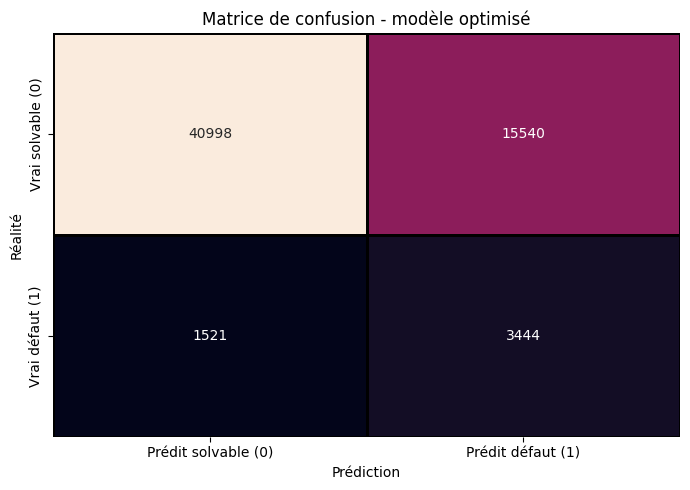

In [29]:
y_pred = best_xgb_pipeline.predict(X_test)
y_prob = best_xgb_pipeline.predict_proba(X_test)[:, 1]

cm = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred, output_dict=True)
cost_test = custom_business_cost(y_test, y_pred) * len(y_test)
roc_auc = roc_auc_score(y_test, y_prob)

print(classification_report(y_test, y_pred))
print(f"ROC-AUC test : {roc_auc:.4f}")
print(f"Pénalité totale test : {cost_test:,.0f}")

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm, annot=True, fmt="d", cbar=False,
    xticklabels=["Prédit solvable (0)", "Prédit défaut (1)"],
    yticklabels=["Vrai solvable (0)", "Vrai défaut (1)"],
    linewidths=1, linecolor="black"
)
plt.title("Matrice de confusion - modèle optimisé")
plt.xlabel("Prédiction")
plt.ylabel("Réalité")
plt.tight_layout()
plt.show()

### Interprétation des performances

Le modèle atteint un ROC-AUC de 0.78, ce qui indique une bonne capacité de discrimination.

Cependant :
- forte précision sur les non-défaillants (classe 0)
- faible précision sur les défaillants (classe 1)

Cela est typique des datasets déséquilibrés.

Le modèle privilégie la réduction du risque global, mais peut encore être amélioré pour mieux détecter les clients à risque.

In [30]:
MODEL_DIR.mkdir(parents=True, exist_ok=True)
joblib.dump(best_xgb_pipeline, MODEL_DIR / "xgboost_baseline.pkl")

test_sample_dashboard = X_test.copy()
test_sample_dashboard["TARGET"] = y_test.values
test_sample_dashboard.to_csv(DATA_PROCESSED / "test_sample_dashboard.csv", index=False)

metrics_summary = pd.DataFrame([{
    "split": "test",
    "roc_auc": roc_auc,
    "precision_1": precision_score(y_test, y_pred, pos_label=1),
    "recall_1": recall_score(y_test, y_pred, pos_label=1),
    "f1_1": f1_score(y_test, y_pred, pos_label=1),
    "business_cost_moyen": custom_business_cost(y_test, y_pred),
    "tn": int(cm[0, 0]),
    "fp": int(cm[0, 1]),
    "fn": int(cm[1, 0]),
    "tp": int(cm[1, 1]),
}])

metrics_summary.to_csv(DATA_PROCESSED / "metrics_summary.csv", index=False)
display(metrics_summary)

print("✅ Modèle, test_sample_dashboard.csv et metrics_summary.csv sauvegardés.")

,split,roc_auc,precision_1,recall_1,f1_1,business_cost_moyen,tn,fp,fn,tp
0,test,0.7789,0.1814,0.6937,0.2876,0.5000,40998,15540,1521,3444


✅ Modèle, test_sample_dashboard.csv et metrics_summary.csv sauvegardés.


## 7. Analyse d'équité (Fairness)

On compare quelques statistiques par groupe lorsque ces colonnes sont disponibles.  
L'objectif n'est pas de conclure à lui seul à une discrimination, mais de repérer des **écarts à surveiller**.

In [31]:
def fairness_by_group(df: pd.DataFrame, group_col: str, y_true_col: str = "TARGET", y_pred_col: str = "PRED"):
    rows = []
    for group_value, g in df.groupby(group_col, dropna=False):
        if len(g) == 0:
            continue
        tn, fp, fn, tp = confusion_matrix(g[y_true_col], g[y_pred_col], labels=[0, 1]).ravel()
        acceptance_rate = (g[y_pred_col] == 0).mean()
        refusal_rate = (g[y_pred_col] == 1).mean()
        fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan
        fnr = fn / (fn + tp) if (fn + tp) > 0 else np.nan

        rows.append({
            "group_col": group_col,
            "group_value": group_value,
            "n": len(g),
            "default_rate_true": g[y_true_col].mean(),
            "acceptance_rate": acceptance_rate,
            "refusal_rate": refusal_rate,
            "FPR": fpr,
            "FNR": fnr,
        })
    return pd.DataFrame(rows).sort_values("n", ascending=False)

fairness_df = X_test.copy()
fairness_df["TARGET"] = y_test.values
fairness_df["PRED"] = y_pred

# groupes utiles possibles
candidate_groups = []
for col in ["CODE_GENDER", "NAME_EDUCATION_TYPE", "NAME_FAMILY_STATUS", "AGE_YEARS"]:
    if col in fairness_df.columns:
        candidate_groups.append(col)

if "AGE_YEARS" in fairness_df.columns:
    fairness_df["AGE_GROUP"] = pd.cut(
        fairness_df["AGE_YEARS"],
        bins=[18, 30, 45, 60, 100],
        labels=["18-30", "31-45", "46-60", "61-100"],
        include_lowest=True
    )
    candidate_groups.append("AGE_GROUP")

candidate_groups = list(dict.fromkeys(candidate_groups))
all_fairness = []

for group_col in candidate_groups:
    res = fairness_by_group(fairness_df, group_col)
    print(f"\nStatistiques d'équité pour {group_col}")
    display(res)
    all_fairness.append(res)

if all_fairness:
    fairness_results = pd.concat(all_fairness, ignore_index=True)
    fairness_results.to_csv(DATA_PROCESSED / "fairness_summary.csv", index=False)
    print("✅ fairness_summary.csv sauvegardé.")
else:
    print("Aucun groupe sensible disponible dans X_test.")


Statistiques d'équité pour CODE_GENDER


,group_col,group_value,n,default_rate_true,acceptance_rate,refusal_rate,FPR,FNR
0,CODE_GENDER,F,40561,0.0699,0.7412,0.2588,0.2303,0.3621
1,CODE_GENDER,M,20940,0.1017,0.5948,0.4052,0.3641,0.2320
2,CODE_GENDER,XNA,2,0.0000,0.0000,1.0000,1.0000,NaN



Statistiques d'équité pour NAME_EDUCATION_TYPE


,group_col,group_value,n,default_rate_true,acceptance_rate,refusal_rate,FPR,FNR
4,NAME_EDUCATION_TYPE,Secondary / secondary special,43623,0.0904,0.6524,0.3476,0.3105,0.2796
1,NAME_EDUCATION_TYPE,Higher education,15061,0.0520,0.8167,0.1833,0.1634,0.4547
2,NAME_EDUCATION_TYPE,Incomplete higher,1988,0.0790,0.6313,0.3687,0.3364,0.2548
3,NAME_EDUCATION_TYPE,Lower secondary,791,0.1037,0.5954,0.4046,0.3667,0.2683
0,NAME_EDUCATION_TYPE,Academic degree,40,0.0250,0.7750,0.2250,0.2308,1.0000



Statistiques d'équité pour NAME_FAMILY_STATUS


...


Statistiques d'équité pour AGE_YEARS


,group_col,group_value,n,default_rate_true,acceptance_rate,refusal_rate,FPR,FNR
864,AGE_YEARS,37.1200,82,0.1341,0.6585,0.3415,0.3099,0.4545
1740,AGE_YEARS,65.0000,81,0.0494,0.8025,0.1975,0.1688,0.2500
1000,AGE_YEARS,41.3800,79,0.0633,0.6962,0.3038,0.2838,0.4000
968,AGE_YEARS,40.3800,78,0.0769,0.8205,0.1795,0.1528,0.5000
1400,AGE_YEARS,53.8800,77,0.0649,0.7143,0.2857,0.2361,0.0000
...,...,...,...,...,...,...,...,...
9,AGE_YEARS,21.1700,1,1.0000,0.0000,1.0000,NaN,0.0000
54,AGE_YEARS,21.8900,1,0.0000,1.0000,0.0000,0.0000,NaN
47,AGE_YEARS,21.7800,1,0.0000,0.0000,1.0000,1.0000,NaN
99,AGE_YEARS,22.6100,1,0.0000,1.0000,0.0000,0.0000,NaN



Statistiques d'équité pour AGE_GROUP


,group_col,group_value,n,default_rate_true,acceptance_rate,refusal_rate,FPR,FNR
1,AGE_GROUP,31-45,24739,0.0883,0.6573,0.3427,0.3047,0.2659
2,AGE_GROUP,46-60,20684,0.0685,0.7591,0.2409,0.2132,0.3832
0,AGE_GROUP,18-30,8910,0.1130,0.4987,0.5013,0.4621,0.1907
3,AGE_GROUP,61-100,7170,0.0497,0.8524,0.1476,0.1331,0.5758


✅ fairness_summary.csv sauvegardé.


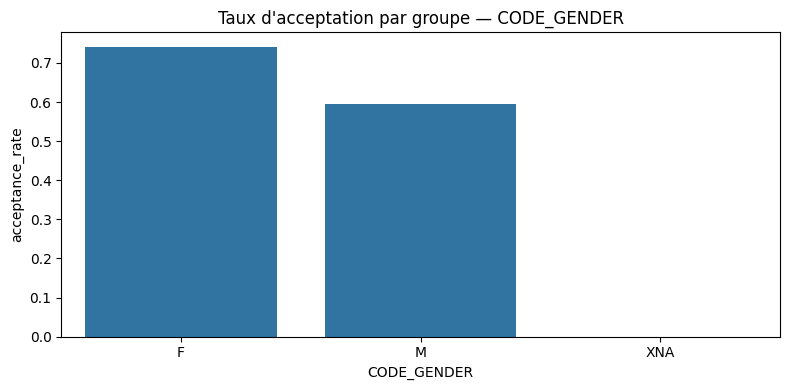

In [32]:
if 'fairness_results' in globals() and not fairness_results.empty:
    group_to_plot = fairness_results["group_col"].iloc[0]
    plot_df = fairness_results[fairness_results["group_col"] == group_to_plot].copy()

    plt.figure(figsize=(8, 4))
    sns.barplot(data=plot_df, x="group_value", y="acceptance_rate")
    plt.title(f"Taux d'acceptation par groupe — {group_to_plot}")
    plt.xlabel(group_to_plot)
    plt.ylabel("acceptance_rate")
    plt.tight_layout()
    plt.show()

### Analyse d’équité

On observe des différences de taux d’acceptation selon les groupes :

- Femmes : 74%
- Hommes : 59%

Cela peut indiquer un biais potentiel du modèle.

Cependant, ces différences peuvent aussi s’expliquer par des différences réelles de distribution du risque.

Une analyse plus approfondie serait nécessaire avant toute conclusion réglementaire.

## 8. Interprétabilité SHAP sur échantillon réduit

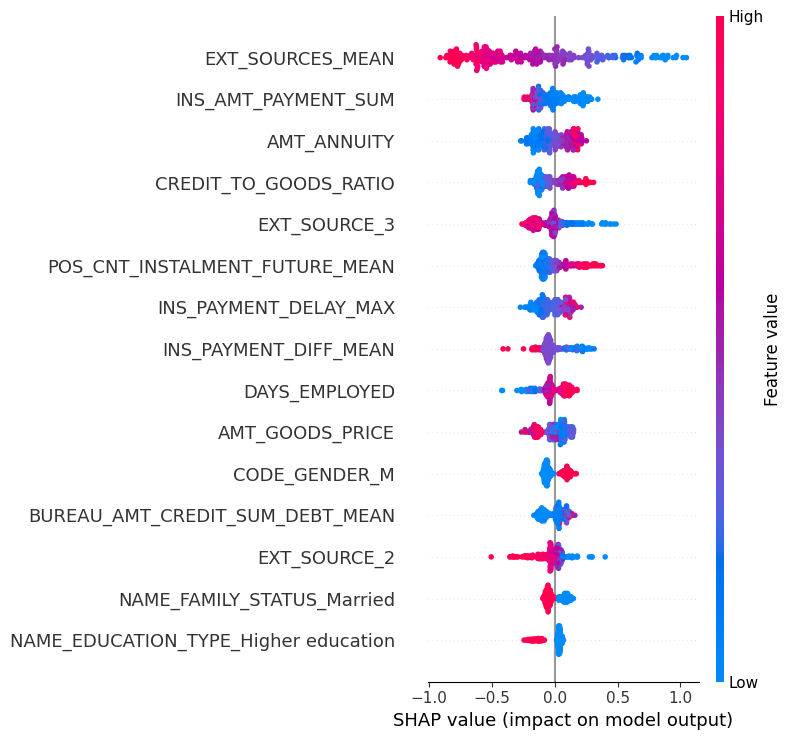

In [33]:
try:
    import shap

    X_test_small = X_test.sample(n=min(300, len(X_test)), random_state=SEED)
    preprocessor_opt = best_xgb_pipeline.named_steps["preprocessor"]
    xgb_model_opt = best_xgb_pipeline.named_steps["classifier"]

    X_test_transformed = preprocessor_opt.transform(X_test_small)

    if hasattr(preprocessor_opt.named_transformers_["cat"].named_steps["onehot"], "get_feature_names_out"):
        ohe_feature_names = preprocessor_opt.named_transformers_["cat"].named_steps["onehot"].get_feature_names_out(categorical_cols)
        all_feature_names = numeric_cols + list(ohe_feature_names)
    else:
        all_feature_names = None

    explainer = shap.TreeExplainer(xgb_model_opt)
    shap_values = explainer.shap_values(X_test_transformed)

    shap.summary_plot(shap_values, X_test_transformed, feature_names=all_feature_names, max_display=15, show=False)
    plt.tight_layout()
    plt.show()
except Exception as e:
    print("SHAP non exécuté :", repr(e))

## 9. Phase 4 — Monitoring et Drift

Le drift est calculé sur des **échantillons de 5 000 lignes** pour limiter la charge mémoire.

In [34]:
try:
    from evidently import Report
    from evidently.presets import DataDriftPreset

    train_data = pd.read_csv(DATA_PROCESSED / "train_final.csv").sample(n=min(5000, len(train_final)), random_state=SEED)
    test_data = pd.read_csv(DATA_PROCESSED / "test_final.csv").sample(n=min(5000, len(test_final)), random_state=SEED)

    reference_data = train_data.drop(columns=[c for c in ["TARGET", "SK_ID_CURR"] if c in train_data.columns])
    current_data = test_data.drop(columns=[c for c in ["TARGET", "SK_ID_CURR"] if c in test_data.columns])

    common_cols = sorted(set(reference_data.columns).intersection(current_data.columns))
    reference_data = reference_data[common_cols]
    current_data = current_data[common_cols]

    report_template = Report(metrics=[DataDriftPreset()])
    drift_eval = report_template.run(reference_data=reference_data, current_data=current_data)

    report_path = DRIFT_DIR / "data_drift_report.html"
    drift_eval.save_html(str(report_path))
    print("✅ Rapport drift sauvegardé :", report_path)
except Exception as e:
    print("Drift Evidently non exécuté :", repr(e))

✅ Rapport drift sauvegardé : /home/alouiyaz/projects/Qualité_controle_données/drift/data_drift_report.html


### Conclusion drift

L’analyse du drift permet de comparer la distribution des données entre train et test.

Elle est essentielle pour détecter une dégradation future du modèle en production.

## Conclusion 

Ce pipeline couvre l’ensemble du cycle de vie d’un modèle de scoring crédit :

- contrôle qualité des données
- feature engineering robuste
- modélisation optimisée
- analyse d’équité
- monitoring du drift

Les résultats sont satisfaisants, mais des améliorations restent possibles :
- gestion du déséquilibre des classes
- amélioration de la détection des défauts
- analyse plus approfondie de l’équité

Ce pipeline est prêt pour une mise en production sous surveillance.

### Fichiers produits
- `data/processed/train_final.csv`
- `data/processed/test_final.csv`
- `data/processed/test_sample_dashboard.csv`
- `data/processed/metrics_summary.csv`
- `data/processed/fairness_summary.csv` (si groupes disponibles)
- `models/xgboost_baseline.pkl`
- `drift/data_drift_report.html`